In [14]:
# IMDB Sentiment Classification using Deep Neural Network
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

In [15]:

df = pd.read_csv(
    'IMDB_Dataset.csv',
    encoding='latin-1',
    engine='python',
    on_bad_lines='skip'
)

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
negative    24813
positive    24799
Name: count, dtype: int64


In [16]:
# Convert labels: 'positive' → 1, 'negative' → 0
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])     # Encodes text labels to numbers
texts = df['review'].values               # Raw text reviews

In [17]:
# Tokenization — convert words to numbers
max_words = 10000                          # Only top 10,000 words
max_len   = 200                            # Max words per review
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)              # Build vocabulary from text
X = tokenizer.texts_to_sequences(texts)   # Convert text to number sequences
X = pad_sequences(X, maxlen=max_len)      # Pad shorter reviews with 0s

In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
# Build the neural network
model = models.Sequential([
  # Embedding: converts word indices into dense vectors
  layers.Embedding(max_words, 32, input_length=max_len),
  # Flatten the 2D embedding into 1D for Dense layers
  layers.GlobalAveragePooling1D(),
  layers.Dense(64, activation='relu'),    # Hidden layer
  layers.Dropout(0.5),                     # Randomly drops 50% neurons (prevents overfitting)
  layers.Dense(1, activation='sigmoid')  # Output: probability 0-1 (sigmoid for binary)
])

C:\Users\shruti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [20]:
# Compile model for binary classification
model.compile(
  optimizer='adam',
  loss='binary_crossentropy',            # Loss for binary (0/1) problems
  metrics=['accuracy']                   # We care about % correct
)

In [22]:

# Train the model
history = model.fit(
  X_train, y_train,
  epochs=5,                                # 5 passes (text training is slower)
  batch_size=64,
  validation_split=0.1,
  verbose=1
)

Epoch 1/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7776 - loss: 0.4718 - val_accuracy: 0.8690 - val_loss: 0.3132
Epoch 2/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8845 - loss: 0.2799 - val_accuracy: 0.8622 - val_loss: 0.3074
Epoch 3/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9052 - loss: 0.2366 - val_accuracy: 0.8823 - val_loss: 0.2743
Epoch 4/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9186 - loss: 0.2101 - val_accuracy: 0.8871 - val_loss: 0.2786
Epoch 5/5
559/559 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9286 - loss: 0.1909 - val_accuracy: 0.8695 - val_loss: 0.3207


In [34]:
# Evaluate on test data
loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {acc*100:.2f}%")

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8762 - loss: 0.3172
Test Accuracy: 87.62%


In [30]:
# Predict sentiment for a new review
sample = ["This movie was absolutely brilliant and wonderful!"]
seq = tokenizer.texts_to_sequences(sample)
seq = pad_sequences(seq, maxlen=max_len)
pred = model.predict(seq)[0][0]
print("Positive" if pred > 0.5 else "Negative", f"({pred:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Positive (0.81)


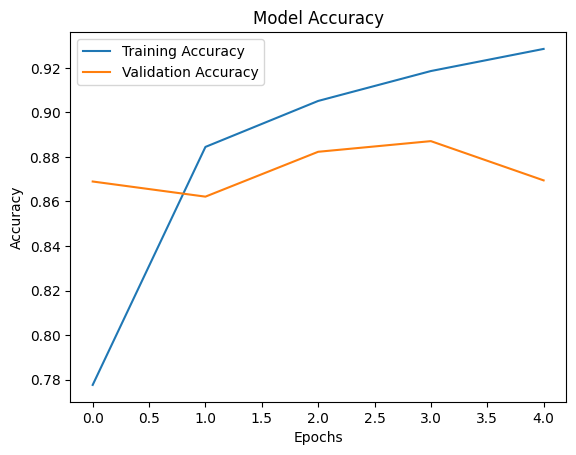

In [33]:
# PLOT ACCURACY GRAPH
# =========================

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()